## Upoznavanje sa podacima

In [2]:
import pandas as pd 

student_info=pd.read_csv("data/raw/studentInfo.csv")

In [3]:
student_info.shape

(32593, 12)

In [4]:
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [5]:
student_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [6]:
student_info.describe()

,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


In [7]:
student_info.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [33]:
print(student_info["final_result"].value_counts())
(student_info["final_result"].value_counts(normalize="index")*100).round(2)

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


final_result
Pass           37.93
Withdrawn      31.16
Fail           21.64
Distinction     9.28
Name: proportion, dtype: float64

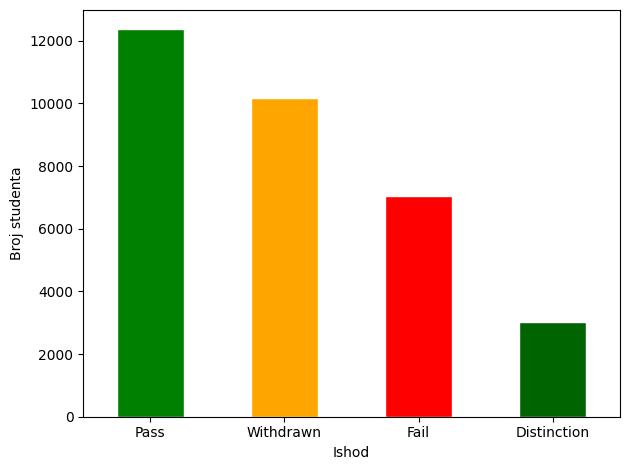

In [37]:
import matplotlib.pyplot as plt

colors=["green", "orange", "red", "darkgreen" ]
student_info["final_result"].value_counts().plot(
    kind="bar",
    color=colors,
    edgecolor="white"
)


plt.xlabel("Ishod")
plt.ylabel("Broj studenta")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
student_info["imd_band"].value_counts()

imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: count, dtype: int64

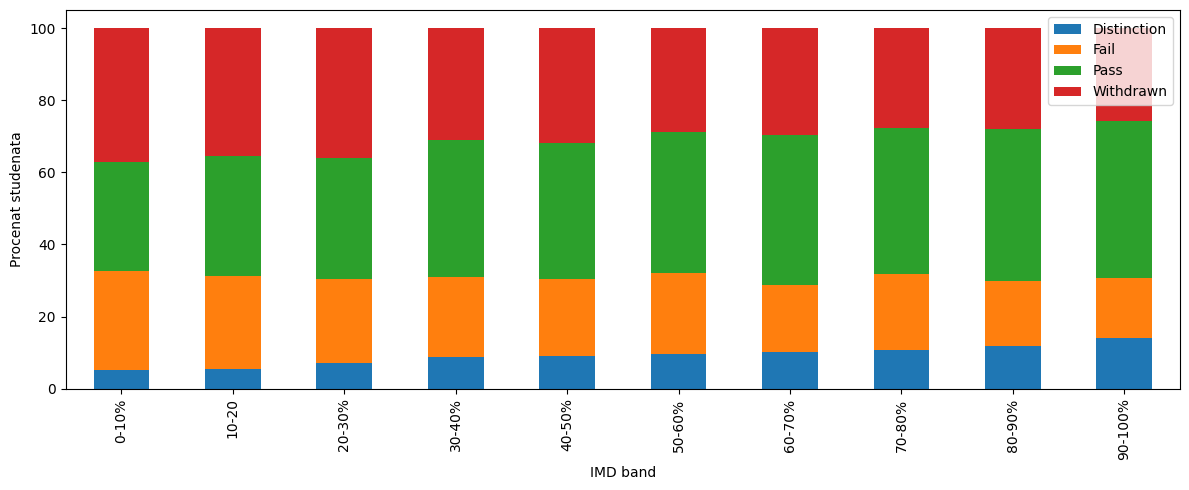

In [ ]:


ct_imd=pd.crosstab(
    student_info["imd_band"],
    student_info["final_result"],
    normalize="index"
)*100
ct_imd.plot(kind="bar", stacked=True, figsize=(12,5))
plt.xlabel("IMD band")
plt.ylabel("Procenat studenata")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [28]:
student_info["highest_education"].value_counts()

highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

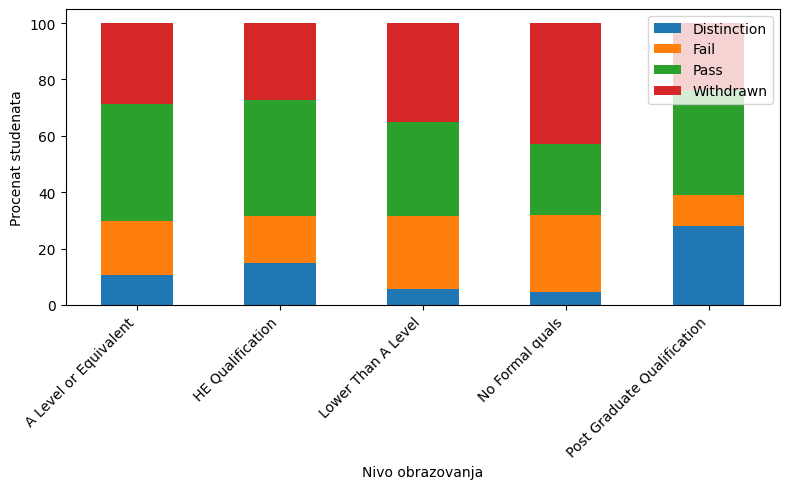

In [76]:
ct_education=pd.crosstab(
    student_info["highest_education"],
    student_info["final_result"],
    normalize="index"
)*100
ct_education.plot(kind="bar", stacked=True, figsize=(8,5))
plt.xlabel("Nivo obrazovanja")
plt.ylabel("Procenat studenata")
plt.legend(loc="upper right")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [44]:
student_info["age_band"].value_counts()

age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

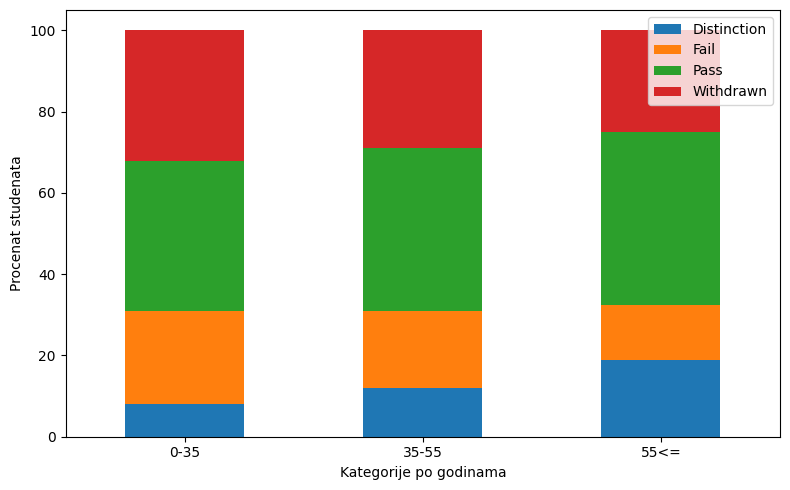

In [75]:
ct_age=pd.crosstab(
    student_info["age_band"],
    student_info["final_result"],
    normalize="index"
)*100
ct_age.plot(kind="bar", stacked=True, figsize=(8,5))
plt.xlabel("Kategorije po godinama")
plt.ylabel("Procenat studenata")
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
student_info["gender"].value_counts()

gender
M    17875
F    14718
Name: count, dtype: int64

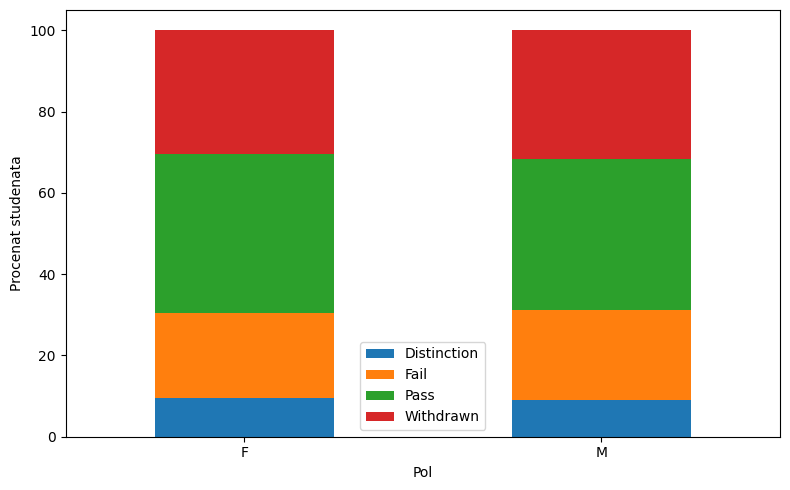

In [82]:
ct_gender=pd.crosstab(
    student_info["gender"],
    student_info["final_result"],
    normalize="index"
)*100
ct_gender.plot(kind="bar", stacked=True, figsize=(8,5))
plt.xlabel("Pol")
plt.ylabel("Procenat studenata")
plt.xticks(rotation=0)
plt.legend(loc="lower center")
plt.tight_layout()
plt.show()

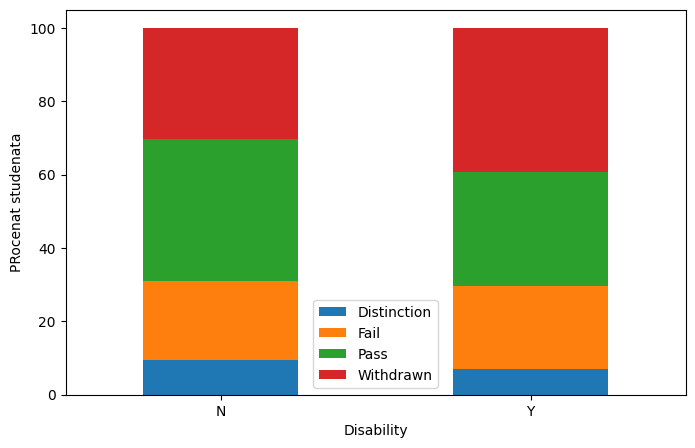

In [81]:
ct_dis = pd.crosstab(
    student_info["disability"],
    student_info["final_result"],
    normalize="index"
) * 100

ct_dis.plot(kind="bar", stacked=True, figsize=(8,5))
plt.xlabel("Disability")
plt.ylabel("PRocenat studenata")
plt.xticks(rotation=0)
plt.legend(loc="lower center")
plt.show()

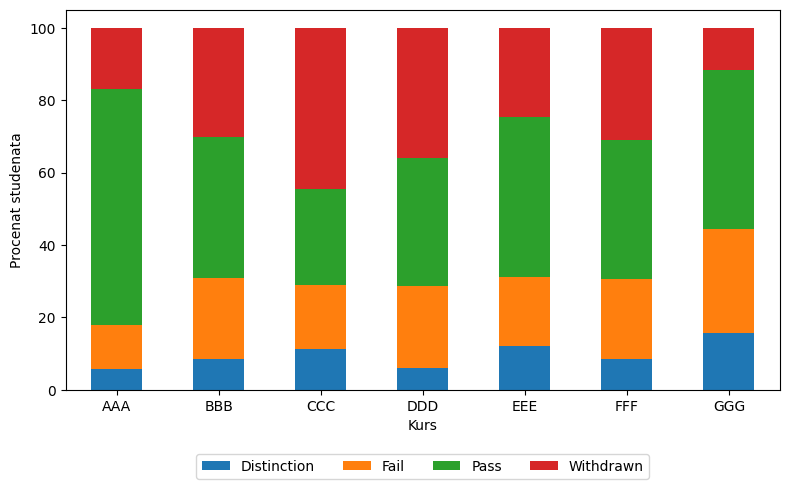

In [115]:
ct_module=pd.crosstab(
    student_info["code_module"],
    student_info["final_result"],
    normalize="index"
)*100
ct_module.plot(kind="bar", stacked=True, figsize=(8,5))
plt.xlabel("Kurs")
plt.ylabel("Procenat studenata")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

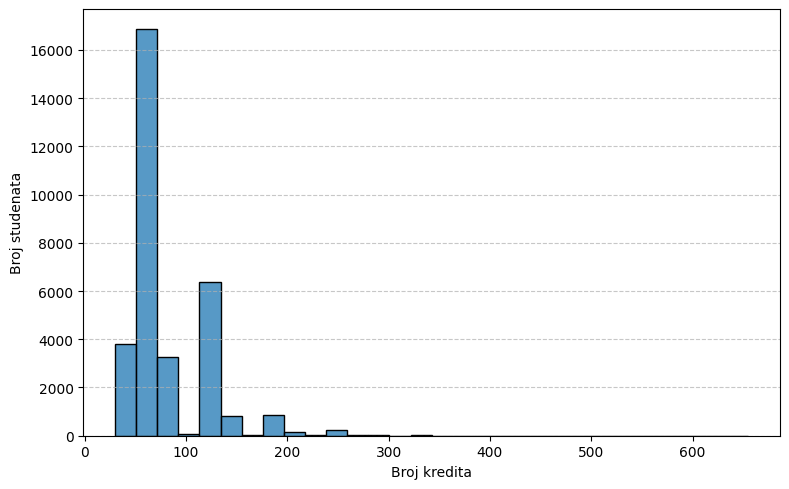

In [ ]:
import seaborn as sb

plt.figure(figsize=(8,5))

sb.histplot(student_info["studied_credits"], bins=30)

plt.xlabel("Broj kredita")
plt.ylabel("Broj studenata")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

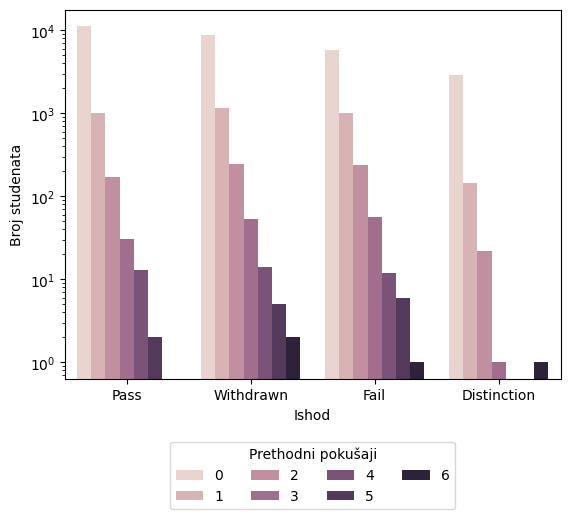

In [53]:
sb.countplot(
    data=student_info, 
    x="final_result", 
    hue="num_of_prev_attempts"
)
plt.legend(title="Prethodni pokušaji", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.xlabel("Ishod")
plt.ylabel("Broj studenata")
plt.yscale('log')

In [18]:
assessments = pd.read_csv("data/raw/assessments.csv")
print("assessments:", assessments.shape)
print("Tipovi zadataka:", assessments["assessment_type"].unique())
assessments.head()

assessments: (206, 6)
Tipovi zadataka: <StringArray>
['TMA', 'Exam', 'CMA']
Length: 3, dtype: str


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [6]:
courses = pd.read_csv("data/raw/courses.csv")
print("courses:", courses.shape)
print("Moduli:", courses["code_module"].unique())
print("Prezentacije:", courses["code_presentation"].unique())
courses.head()

courses: (22, 3)
Moduli: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
Length: 7, dtype: str
Prezentacije: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [27]:
vle = pd.read_csv("data/raw/vle.csv")
print("vle:", vle.shape)
print("Broj aktivnosti u VLE:", vle["activity_type"].unique())
vle.head()

vle: (6364, 6)
Broj aktivnosti u VLE: <StringArray>
[      'resource',      'oucontent',            'url',       'homepage',
        'subpage',       'glossary',        'forumng',  'oucollaborate',
       'dataplus',           'quiz',   'ouelluminate',  'sharedsubpage',
  'questionnaire',           'page',   'externalquiz',         'ouwiki',
       'dualpane', 'repeatactivity',         'folder',   'htmlactivity']
Length: 20, dtype: str


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [28]:
student_registration = pd.read_csv("data/raw/studentRegistration.csv")
print("student_registration:", student_registration.shape)
student_registration.head()

student_registration: (32593, 5)


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [8]:
student_assessment = pd.read_csv("data/raw/studentAssessment.csv")
print("student_assessment:", student_assessment.shape)
student_assessment.head()

student_assessment: (173912, 5)


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [9]:
student_vle = pd.read_csv("data/raw/studentVle.csv")
print("student_vle:", student_vle.shape)
student_vle.head()

student_vle: (10655280, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
